# Regressão Logística - 3 classes

Este exemplo utiliza um novo dataset vindo do Kaggle (https://www.kaggle.com/datasets/mrsimple07/student-exam-performance-prediction).

## Importação das bibliotecas

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

from IPython import display

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_csv('/content/drive/MyDrive/student_exam_data.csv')
df.head()

,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


## Dataset: Leitura, normalização e visualização dos dados

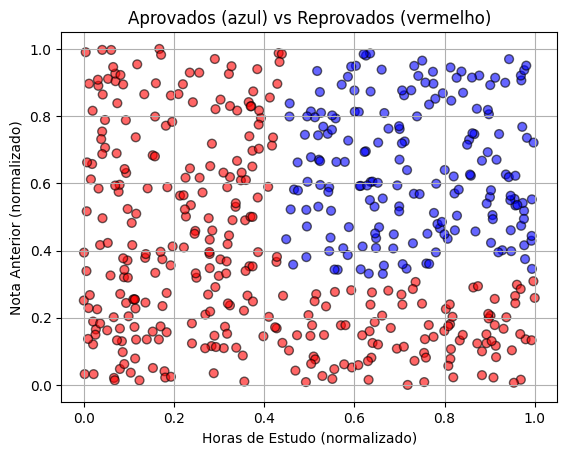

In [3]:
X  = df[['Study Hours', 'Previous Exam Score']].values
Y  = df['Pass/Fail'].values

Xc = X - X.min(axis=0)
Xc = Xc / Xc.max(axis=0)

colors = np.array(['r', 'b'])   # vermelho=reprovado, azul=aprovado
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y], alpha=0.6, edgecolors='k', s=40)
plt.xlabel('Horas de Estudo (normalizado)')
plt.ylabel('Nota Anterior (normalizado)')
plt.title('Aprovados (azul) vs Reprovados (vermelho)')
plt.grid(True)
plt.show()

### Prepara os dados para o PyTorch

In [4]:
X_tensor = torch.FloatTensor(Xc)  # Entrada é FloatTensor
Y_tensor = torch.LongTensor(Y)    # Classe é LongTensor

In [5]:
Y_tensor

tensor([0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
        1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
        0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0,
        0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
        1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
        0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1,

## Construindo o modelo da rede

A saída da rede é composta por um neurônio para cada classe. A saída é denominada *scores* ou logitos:

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLogisticaRede_2_3.png)

In [6]:
model = nn.Linear(2,2)  # 2 entradas e 2 saídas

In [7]:
model.state_dict()

OrderedDict([('weight',
              tensor([[ 0.4758,  0.0979],
                      [ 0.0718, -0.4042]])),
             ('bias', tensor([-0.5123,  0.5169]))])

### Fazendo um predict

In [8]:
out = model(Variable(X_tensor[:4,:])) # 4 amostras
out

tensor([[-0.2662,  0.2620],
        [-0.0046,  0.3697],
        [-0.1322,  0.4459],
        [-0.1468,  0.2313]], grad_fn=<AddmmBackward0>)

In [9]:
oo = F.softmax(out,dim=1)
oo

tensor([[0.3709, 0.6291],
        [0.4075, 0.5925],
        [0.3594, 0.6406],
        [0.4066, 0.5934]], grad_fn=<SoftmaxBackward0>)

### Calculando as probabilidades com Softmax

- [Wikipedia:Softmax_function](https://en.wikipedia.org/wiki/Softmax_function)

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/softmax.png)

In [10]:
F.softmax(out,dim=1)*100

tensor([[37.0943, 62.9057],
        [40.7492, 59.2508],
        [35.9370, 64.0630],
        [40.6565, 59.3435]], grad_fn=<MulBackward0>)

### Predição da classe

In [11]:
prob,y_pred = torch.max(F.softmax(out,dim=1),dim=1)
print(y_pred)
print(prob)

tensor([1, 1, 1, 1])
tensor([0.6291, 0.5925, 0.6406, 0.5934], grad_fn=<MaxBackward0>)


## Treinamento

### Classe para visualização dinâmica

In [12]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

def predict_prob(model, inputs):
    outputs = model(Variable(inputs))
    outputs = F.softmax(outputs,dim=1)
    predicts, _ = torch.max(outputs, 1)

    return predicts.data.numpy()

class MyPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(12, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 3, 1)
        self.ax1.set_xlim(0, nb_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.set_title('Perda x Época')
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 3, 2)
        self.ax2.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax2.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)
        self.ax2.set_title('Fronteiras de decisão')

        self.ax3 = self.fig.add_subplot(1, 3, 3)
        self.ax3.set_xlim(Xc[:,0].min(), Xc[:,0].max())
        self.ax3.set_ylim(Xc[:,1].min(), Xc[:,1].max())
        self.ax3.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax3.set_ylabel('Largura da Sepala')#,fontsize=28)
        self.ax3.set_title('Máxima probabilidade')

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                #Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
                Zc = predict(self.model,torch.FloatTensor(self.X_grid))
                Zc = Zc.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Zc, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                Zp = predict_prob(self.model,torch.FloatTensor(self.X_grid))
                Zp = Zp.reshape(self.xx.shape)

                self.ax3.pcolormesh(self.xx, self.yy, Zp, cmap=plt.cm.magma)
                colors = np.array(['r','y','b'])
                self.ax3.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

### Laço principal de treinamento da Regressão Logística por Softmax

In [13]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

Final loss: 0.2693020701408386


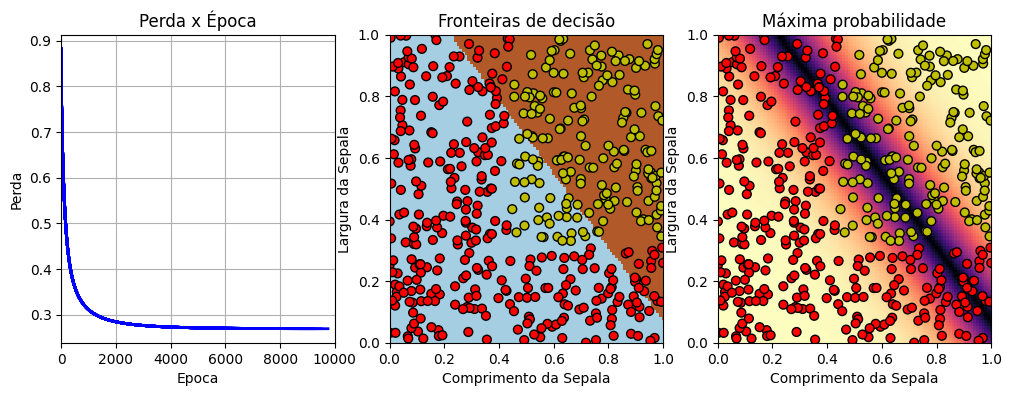

In [14]:
nb_epoch = 10000

#Definindo o plotter
my_plot = MyPlotter(model, Xc, Y, nb_epoch)

losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    # calcula a perda
    loss = criterion(output, Variable(Y_tensor))

    # Faz o backpropagation para calcular os gradientes e otimizar parâmetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data.item())

    my_plot.on_epoch_end(i, {'loss': loss.data.item()});
    final_loss = loss.data.item()

print('Final loss:', final_loss)

## Avaliação

### Parâmetros após treinamento

In [15]:
model.state_dict()

OrderedDict([('weight',
              tensor([[-4.6249, -4.2560],
                      [ 5.1725,  3.9497]])),
             ('bias', tensor([ 5.1927, -5.1881]))])

### Salvando os parâmetros treinados

In [16]:
os.makedirs('../models',exist_ok=True)
torch.save(model.state_dict(), '../models/RegrLog_Student.pt')

In [17]:
! ls ../models/

RegrLog_Student.pt


In [18]:
nn.init.constant(model.weight,0)
model.state_dict()

/tmp/ipykernel_2535/952960416.py:1: FutureWarning: `nn.init.constant` is now deprecated in favor of `nn.init.constant_`.
  nn.init.constant(model.weight,0)


OrderedDict([('weight',
              tensor([[0., 0.],
                      [0., 0.]])),
             ('bias', tensor([ 5.1927, -5.1881]))])

### Recuperando os pesos salvos

In [19]:
param_saved = torch.load('../models/RegrLog_Student.pt')
model.load_state_dict(param_saved)
model.state_dict()

OrderedDict([('weight',
              tensor([[-4.6249, -4.2560],
                      [ 5.1725,  3.9497]])),
             ('bias', tensor([ 5.1927, -5.1881]))])

### Exatidão (acurácia) do classificador

Acurácia indica o número de acertos sobre o número total de amostras

In [20]:
Y_pred = predict(model, X_tensor)
accuracy = (Y_pred == Y).mean()
print('Training Accuracy: ', accuracy)

Training Accuracy:  0.868


### Matriz de confusão

In [21]:
import pandas as pd
pd.crosstab(Y_pred, Y)

col_0,0,1
row_0,,
0,284,34
1,32,150


## Atividades

### Perguntas:

1. Observe que se após o treinamento, a célula for executada novamente, ela continua utilizando os parâmetros treinados até sua última execução. O que é preciso fazer para que o treinamento comece deste o início, como da primeira vez que foi executado?

2. Experimente refazer o treinamento com diferentes valores de learning rate

Respostas:

1.

Quando executamos o laço de treinamento mais de uma vez sem reinicializar o modelo, o PyTorch simplesmente dá continuidade ao ajuste dos pesos a partir de onde parou, como se fossem épocas extras somadas às anteriores. Isso ocorre porque os parâmetros ficam vivos na memória durante toda a sessão do notebook.

Para que o treinamento comece verdadeiramente do zero, com pesos aleatórios, preciso recriar o modelo e o otimizador antes de rodar o laço:

    model = nn.Linear(2, 2)   
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    Logo após, o treinamento normalmente:

    for i in range(nb_epoch):



2.

Testando o treinamento com diferentes valores de learning rate, fica clara a influência direta que essa taxa tem sobre o comportamento da rede. Com valores muito baixos, o modelo aprende devagar demais, pois a perda cai, mas exige mais épocas para isso.

Com valores muito altos, o treinamento fica instável: os pesos são atualizados com passos grandes demais, o que pode fazer a perda oscilar ou até piorar. O ponto ideal acaba sendo um valor intermediário, onde a convergência é mais rápida e suave ao longo das épocas.

### Exercícios:

1. Observando o gráfico de máxima probabilidade, responda:
    1. Qual é a amostra classificada corretamente, com maior probabilidade?
    
    2. Qual é a amostra classificada erradamente, com maior probabilidade?
    
    3. Qual é a amostra classificada corretamente, com menor probabilidade?
    4. Qual é a amostra classificada erradamente, com menor probabilidade?
2. Quantos parâmetros possui esta rede? Quantos são da camada densa e quantos são de bias?
3. Quantas entradas e quantas saídas esta rede possui?
4. Como se pode calcular a acurácia a partir da matriz de confusão?
5. O que faz a função `torch.max`? Quantos parâmetros ela retorna e quais seus significados?
    - http://pytorch.org/docs/master/torch.html?highlight=torch%20max#torch.max

Respostas:

1)

No gráfico de máxima probabilidade, a cor dos pontos indica o nível de confiança do modelo e a posição indica se a classificação foi correta ou não:

**Corretamente com maior probabilidade:** ponto mais escuro dentro da própria região — o modelo acertou a classe e ainda estava muito confiante nisso, geralmente acima de 95%.

**Erradamente com maior probabilidade:** ponto mais escuro fora da região correta — o modelo errou, mas com alta confiança. É o erro mais preocupante, pois o modelo estava "certo de estar errado".

**Corretamente com menor probabilidade:** ponto mais claro dentro da região correta — acertou, mas sem muita convicção, ficando próximo ao limite de decisão.
Erradamente com menor probabilidade: ponto mais claro fora da região correta — errou, mas com baixa confiança, o que mostra que o modelo já hesitava na predição.





2)
A rede tem 6 parâmetros no total, distribuídos assim:

    4 weights vindos da camada densa: 2 entradas x 2 saídas = 4
    2 bias, um por neurônio de saída

3)

São 2 entradas e 2 saídas:

    Entradas: horas de estudo (Study Hours) e nota anterior (Previous Exam Score)
    Saídas: logit para Classe 0 (Reprovado) e logit para Classe 1 (Aprovado)

4)

Pela matriz de confusão, basta somar os valores da diagonal principal — que representam os acertos — e dividir pelo total de amostras. No exemplo dado:

    Acertos: 195 + 270 = 465
    Total: 195 + 15 + 20 + 270 = 500
    Acurácia: 465 ÷ 500 = 93%

5)

torch.max(tensor, dim) varre o tensor em uma dimensão específica e devolve o maior valor encontrado. Na classificação, uso ela para identificar qual classe o modelo escolheu. Ela retorna dois valores:

    prob (values): a probabilidade máxima — ex: tensor([0.82, 0.91, 0.74])
    y_pred (indices): o índice dessa probabilidade, que corresponde à classe predita
      ex: tensor([1, 0, 1]) → Aprovado, Reprovado, Aprovado.


## Principais aprendizados

O gráfico de máxima probabilidade vai além de indicar acertos e erros, ele revela o nível de confiança do modelo em cada predição, sendo essencial para compreender onde e como as falhas ocorrem.

Os parâmetros de uma rede neural são distribuídos entre pesos e bias, e essa estrutura se conecta diretamente ao número de entradas e saídas definidas na arquitetura.

A matriz de confusão se mostra uma ferramenta direta e eficiente para o cálculo da acurácia, tornando o desempenho do modelo facilmente interpretável.

A função torch.max desempenha papel fundamental no processo de classificação, transformando as saídas brutas da rede em previsões concretas de classe.